In [1]:
!pip install ultralytics roboflow -q

In [2]:
from roboflow import Roboflow
from ultralytics import YOLO
import os, sys
env_bin = os.path.dirname(sys.executable)   # .../yolo-env/bin
os.environ["PATH"] = env_bin + ":" + os.environ.get("PATH", "")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/franciscoyan/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# dataset 1 - original dataset, clean
rf = Roboflow(api_key="WkFpt7wTr1fYgve68eNC")
project = rf.workspace("surgical-tools").project("surgical-tools-dataset")
version = project.version(2)
dataset1 = version.download("yolo26")
path1 = dataset1.location

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Surgical-Tools-Dataset-2 in yolo26:: 100%|██████████| 18734/18734 [00:01<00:00, 11465.07it/s]


In [5]:
# + dataset 2 - the one Preston found, includes dirty/overlapping
rf = Roboflow(api_key="opHZYgh4BWTiRwE5MqdS")
project = rf.workspace("strykervisionmdp").project("surgical-tools-jss14-fk7uq")
version = project.version(1)
dataset2 = version.download("yolo26")
path2 = dataset2.location

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Surgical-Tools-1 in yolo26:: 100%|██████████| 11656/11656 [00:01<00:00, 11556.83it/s]


In [6]:
print(path1)

/Users/franciscoyan/Documents/projects/MDP-stryker-cv/Surgical-Tools-Dataset-2


In [8]:

from pathlib import Path
import yaml, shutil
from collections import Counter

def relabel_yolo_dataset(
    src_root: Path,               # folder containing data.yaml + train/valid/test
    dst_root: Path,               # new folder to create
    master_names: list[str],       # final unified class list (order matters)
    src_name_to_master: dict,      # mapping: src class name -> master class name (or None to hold out)
    splits=("train", "valid", "test"),
    copy_images=True,             # True = copy images; False = symlink
    holdout_root: Path | None = None,  # if provided, samples containing a None-mapped class are copied here
):
    """Relabel a YOLO-format dataset into a unified class taxonomy.

    - Any source class not present in src_name_to_master is DROPPED (those label lines removed).
    - If src_name_to_master[class_name] is None, the ENTIRE IMAGE is HELD OUT:
        - It is NOT written to dst_root.
        - If holdout_root is provided, the original image+label are copied there (same split).
    """

    src_yaml = src_root / "data.yaml"
    with open(src_yaml, "r") as f:
        cfg = yaml.safe_load(f)

    src_names = cfg["names"]
    master_id = {n: i for i, n in enumerate(master_names)}

    # Build old_id -> new_id, and old_ids that trigger holdout
    oldid_to_newid = {}
    holdout_oldids = set()
    missing = []
    bad_master = []

    for old_id, old_name in enumerate(src_names):
        if old_name not in src_name_to_master:
            missing.append(old_name)
            continue
        new_name = src_name_to_master[old_name]
        if new_name is None:
            holdout_oldids.add(old_id)
            continue
        if new_name not in master_id:
            bad_master.append((old_name, new_name))
            continue
        oldid_to_newid[old_id] = master_id[new_name]

    print(f"\n=== {src_root.name} → {dst_root.name} ===")
    if missing:
        print("⚠️ Missing mappings (these classes will be dropped):")
        for m in missing:
            print(" -", m)
    if bad_master:
        print("⚠️ Mappings to unknown master classes (these will be dropped):")
        for old_name, new_name in bad_master:
            print(f" - {old_name} -> {new_name} (not in master_names)")
    if holdout_oldids:
        holdout_names = [src_names[i] for i in sorted(holdout_oldids)]
        print("🧪 Holdout trigger classes (whole images will be excluded):", holdout_names)
    if (not missing) and (not bad_master):
        print("✅ All source classes mapped (or intentionally held out).")

    def split_img_dir(split): return src_root / split / "images"
    def split_lbl_dir(split): return src_root / split / "labels"

    counts_old = Counter()
    counts_new = Counter()

    for split in splits:
        img_in = split_img_dir(split)
        lbl_in = split_lbl_dir(split)

        img_out = dst_root / split / "images"
        lbl_out = dst_root / split / "labels"
        img_out.mkdir(parents=True, exist_ok=True)
        lbl_out.mkdir(parents=True, exist_ok=True)

        # Holdout dirs (optional)
        if holdout_root is not None:
            h_img_out = holdout_root / split / "images"
            h_lbl_out = holdout_root / split / "labels"
            h_img_out.mkdir(parents=True, exist_ok=True)
            h_lbl_out.mkdir(parents=True, exist_ok=True)
        else:
            h_img_out = h_lbl_out = None

        kept_stems = set()
        skipped_stems = set()

        # 1) Process labels first (decide keep/skip)
        for lab in lbl_in.glob("*.txt"):
            out_lines = []
            skip_whole = False

            for line in lab.read_text().splitlines():
                if not line.strip():
                    continue
                parts = line.split()
                old_id = int(parts[0])
                counts_old[old_id] += 1

                # If this class is a holdout trigger, skip entire sample
                if old_id in holdout_oldids:
                    skip_whole = True
                    break

                # If class is not mapped, drop the line
                if old_id not in oldid_to_newid:
                    continue

                new_id = oldid_to_newid[old_id]
                parts[0] = str(new_id)
                out_lines.append(" ".join(parts))
                counts_new[new_id] += 1

            stem = lab.stem
            if skip_whole:
                skipped_stems.add(stem)

                # Optionally copy original label + image to holdout_root
                if h_lbl_out is not None:
                    shutil.copy2(lab, h_lbl_out / lab.name)

                    # copy matching image if exists
                    img = None
                    for ext in (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"):
                        cand = img_in / f"{stem}{ext}"
                        if cand.exists():
                            img = cand
                            break
                    if img is not None:
                        shutil.copy2(img, h_img_out / img.name)
                continue

            # Keep sample in dst: write relabeled label file (may be empty)
            (lbl_out / lab.name).write_text("\n".join(out_lines) + ("\n" if out_lines else ""))
            kept_stems.add(stem)

        # 2) Copy/symlink images for kept samples + any unlabeled images (unless explicitly skipped)
        for p in img_in.glob("*"):
            if not p.is_file():
                continue
            stem = p.stem
            if stem in skipped_stems:
                continue
            if (stem in kept_stems) or not (lbl_in / f"{stem}.txt").exists():
                target = img_out / p.name
                if copy_images:
                    shutil.copy2(p, target)
                else:
                    if not target.exists():
                        target.symlink_to(p)

    # Write new yaml (absolute paths)
    out_yaml = {
        "train": str((dst_root / "train/images").resolve()),
        "val":   str((dst_root / "valid/images").resolve()),
        "test":  str((dst_root / "test/images").resolve()),
        "nc": len(master_names),
        "names": master_names,
    }
    dst_root.mkdir(parents=True, exist_ok=True)
    with open(dst_root / "data.yaml", "w") as f:
        yaml.safe_dump(out_yaml, f, sort_keys=False)

    print("Old boxes:", sum(counts_old.values()), " New boxes:", sum(counts_new.values()))
    print("✅ Wrote:", dst_root / "data.yaml")
    if holdout_root is not None:
        print("🧪 Holdout saved to:", holdout_root.resolve())
    return counts_new

In [9]:
from pathlib import Path

master_names = [
    "scissors","forceps","bp_handle","dissector","scalpel","syringe"
]

# Dataset 1 (18-class) mapping (yours)
map_ds1 = {
    "7 Metzenbaum Scissors": "scissors",
    "9 Metzenbaum Scissors": "scissors",
    "Curved Mayo Scissors": "scissors",
    "Dressing Scissors": "scissors",
    "Allis Tissue Forceps": "forceps",
    "8 Babcock Tissue Forceps": "forceps",
    "Babcock Tissue Forceps": "forceps",
    "Crile Artery Forceps": "forceps",
    "Lahey Forceps": "forceps",
    "Sponge Forceps": "forceps",
    "8 Mayo Needle Holder": "forceps",
    "Mayo Needle Holder": "forceps",
    "No.3 BP Handle": "bp_handle",
    "No.4 BP Handle": "bp_handle",
    "DeBakey Dissector": "dissector",
    "Gillies Toothed Dissector": "dissector",
    "8": None,
    "9": None,
}

# Dataset 2 (8-class) mapping:
# - We do NOT want to map "Overlapping" to a training class.
# - Set it to None to HOLD OUT any image that contains that class label.
map_ds2 = {
    "Hemostat": "forceps",
    "Mayo": "scissors",
    "Overlapping": None,   # <-- holdout trigger (whole image excluded from training set)
    "Scalpel": "scalpel",
    "Stitch Scissors": "scissors",
    "episiotomy-scissors": "scissors",
    "forceps": "forceps",
    "syringe": "syringe",
}

counts1 = relabel_yolo_dataset(
    src_root=Path(path1),
    dst_root=Path("d1-unifyclass"),
    master_names=master_names,
    src_name_to_master=map_ds1,
)

path1 = Path("d1-unifyclass")
counts2 = relabel_yolo_dataset(
    src_root=Path(path2),
    dst_root=Path("d2-unifyclass"),
    master_names=master_names,
    src_name_to_master=map_ds2,
    holdout_root=Path("d2-holdout-overlapping"),
)
path2 = Path("d2-unifyclass")


=== Surgical-Tools-Dataset-2 → d1-unifyclass ===
🧪 Holdout trigger classes (whole images will be excluded): ['8', '9']
✅ All source classes mapped (or intentionally held out).
Old boxes: 9610  New boxes: 8686
✅ Wrote: d1-unifyclass/data.yaml

=== Surgical-Tools-1 → d2-unifyclass ===
🧪 Holdout trigger classes (whole images will be excluded): ['Overlapping']
✅ All source classes mapped (or intentionally held out).
Old boxes: 5967  New boxes: 4490
✅ Wrote: d2-unifyclass/data.yaml
🧪 Holdout saved to: /Users/franciscoyan/Documents/projects/MDP-stryker-cv/d2-holdout-overlapping


In [11]:
from pathlib import Path
import shutil, yaml, random
from collections import Counter

# --- Configuration ---
DS1 = Path(path1)
DS2 = Path(path2)
OUT = Path("d1d2_stratified")

if OUT.exists():
    shutil.rmtree(OUT)
ratios = {"train": 0.70, "valid": 0.15, "test": 0.15}

def load_yaml(p: Path):
    with open(p, "r") as f:
        return yaml.safe_load(f)

cfg1 = load_yaml(DS1 / "data.yaml")
master_names = cfg1["names"]

# --- 1. Collect all data ---
print("▶ Gathering all images and parsing labels...")
samples = []
class_totals = Counter()

for ds_path, prefix in [(DS1, "d1"), (DS2, "d2")]:
    for split in ["train", "valid", "test"]:
        img_dir = ds_path / split / "images"
        lbl_dir = ds_path / split / "labels"

        if not img_dir.exists():
            continue

        for img_path in img_dir.iterdir():
            if not img_path.is_file():
                continue

            stem = img_path.stem
            lbl_path = lbl_dir / f"{stem}.txt"

            counts = Counter()
            if lbl_path.exists():
                lines = lbl_path.read_text().strip().splitlines()
                for line in lines:
                    if line.strip():
                        c = int(line.split()[0])
                        counts[c] += 1
                        class_totals[c] += 1

            samples.append({
                "src_img": img_path,
                "src_lbl": lbl_path if lbl_path.exists() else None,
                "new_stem": f"{prefix}_{stem}",
                "counts": counts
            })

print(f"Total images found: {len(samples)}")
print(f"Total instances per class: {dict(class_totals)}")

# --- 2. Stratified Allocation (Greedy Algorithm) ---
print("\n▶ Calculating 70/15/15 stratified splits...")

# Sort samples so images containing the *rarest* classes are distributed first
def rarity_weight(sample):
    w = 0
    for c, count in sample["counts"].items():
        w += count * (1.0 / class_totals[c]) # Higher weight for rare classes
    return w

random.seed(42)
random.shuffle(samples) # Break ties randomly
samples.sort(key=rarity_weight, reverse=True)

targets_cls = {s: {c: total * ratios[s] for c, total in class_totals.items()} for s in ratios}
current_cls = {s: {c: 0 for c in class_totals.keys()} for s in ratios}

targets_img = {s: len(samples) * ratios[s] for s in ratios}
current_img = {s: 0 for s in ratios}

splits_assignment = {"train": [], "valid": [], "test": []}

for s in samples:
    best_split = None
    best_score = -float('inf')

    # If it's a background image (no labels), assign based on total image capacity
    if not s["counts"]:
        for split in ratios:
            score = (targets_img[split] - current_img[split]) / targets_img[split]
            if score > best_score:
                best_score = score
                best_split = split
    else:
        # Assign to the split that has the highest deficit for the classes in this image
        for split in ratios:
            score = 0
            for c, count in s["counts"].items():
                if targets_cls[split][c] > 0:
                    # Calculate percentage deficit
                    deficit = (targets_cls[split][c] - current_cls[split][c]) / targets_cls[split][c]
                    score += deficit * count

            # Slight penalty if a split is hogging too many total images
            img_deficit = (targets_img[split] - current_img[split]) / targets_img[split]
            score += img_deficit * 0.5

            if score > best_score:
                best_score = score
                best_split = split

    # Register assignment
    splits_assignment[best_split].append(s)
    current_img[best_split] += 1
    for c, count in s["counts"].items():
        current_cls[best_split][c] += count

# --- 3. Copy files to new structure ---
print("\n▶ Copying files to new stratified dataset...")

for split in ratios:
    img_out = OUT / split / "images"
    lbl_out = OUT / split / "labels"
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    for i, s in enumerate(splits_assignment[split], 1):
        new_img_name = f"{s['new_stem']}{s['src_img'].suffix}"
        shutil.copy2(s["src_img"], img_out / new_img_name)

        new_lbl_name = f"{s['new_stem']}.txt"
        if s["src_lbl"]:
            shutil.copy2(s["src_lbl"], lbl_out / new_lbl_name)
        else:
            (lbl_out / new_lbl_name).write_text("") # empty label for background images

        if i % 1000 == 0:
            print(f"   {split}: copied {i}/{len(splits_assignment[split])} images")

    print(f"✔ Finished {split} -> {len(splits_assignment[split])} images")

# --- 4. Write data.yaml ---
merged_yaml = {
    "train": str((OUT / "train/images").resolve()),
    "val":   str((OUT / "valid/images").resolve()),
    "test":  str((OUT / "test/images").resolve()),
    "nc": len(master_names),
    "names": master_names,
}
with open(OUT / "data.yaml", "w") as f:
    yaml.safe_dump(merged_yaml, f, sort_keys=False)

print(f"\n✅ Stratified dataset created at: {OUT}")

# --- 5. Print Distribution Validation ---
print("\n=== Final Class Distribution vs Target ===")
for c_idx, c_name in enumerate(master_names):
    if c_idx not in class_totals:
        continue
    print(f"\n{c_name} (Total: {class_totals[c_idx]}):")
    for split in ratios:
        actual = current_cls[split][c_idx]
        target = targets_cls[split][c_idx]
        pct = (actual / class_totals[c_idx]) * 100
        print(f"  - {split}: {actual} ({pct:.1f}%) [Target: {target:.1f}]")

▶ Gathering all images and parsing labels...
Total images found: 12782
Total instances per class: {1: 4784, 2: 1211, 3: 834, 0: 5121, 4: 620, 5: 606}

▶ Calculating 70/15/15 stratified splits...

▶ Copying files to new stratified dataset...
   train: copied 1000/8946 images
   train: copied 2000/8946 images
   train: copied 3000/8946 images
   train: copied 4000/8946 images
   train: copied 5000/8946 images
   train: copied 6000/8946 images
   train: copied 7000/8946 images
   train: copied 8000/8946 images
✔ Finished train -> 8946 images
   valid: copied 1000/1918 images
✔ Finished valid -> 1918 images
   test: copied 1000/1918 images
✔ Finished test -> 1918 images

✅ Stratified dataset created at: d1d2_stratified

=== Final Class Distribution vs Target ===

scissors (Total: 5121):
  - train: 3584 (70.0%) [Target: 3584.7]
  - valid: 769 (15.0%) [Target: 768.1]
  - test: 768 (15.0%) [Target: 768.1]

forceps (Total: 4784):
  - train: 3348 (70.0%) [Target: 3348.8]
  - valid: 718 (15.0%) 

Found 4942 candidate images for 'scissors'


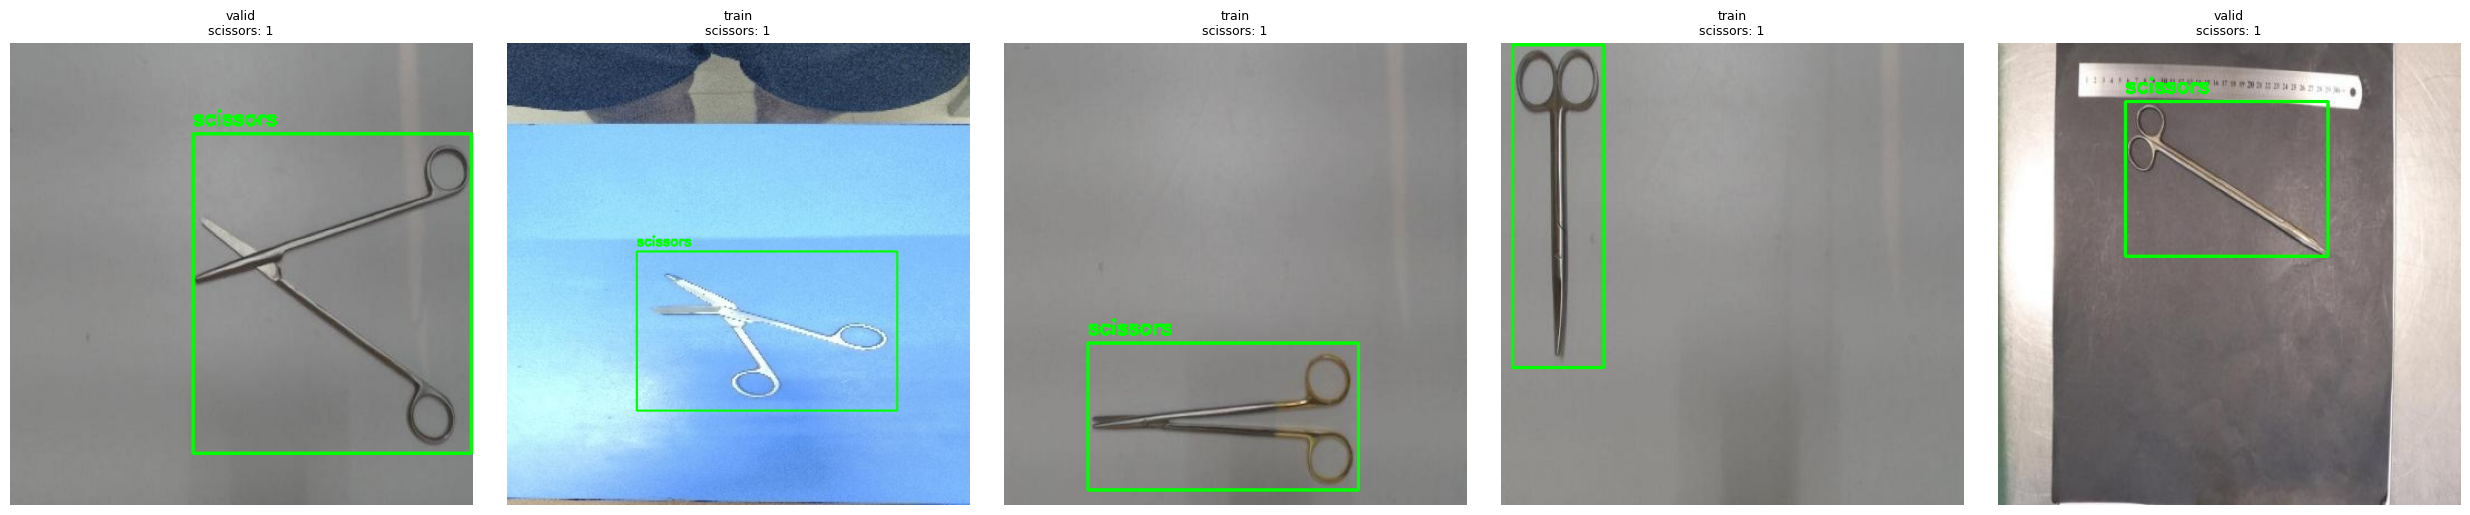

Found 4575 candidate images for 'forceps'


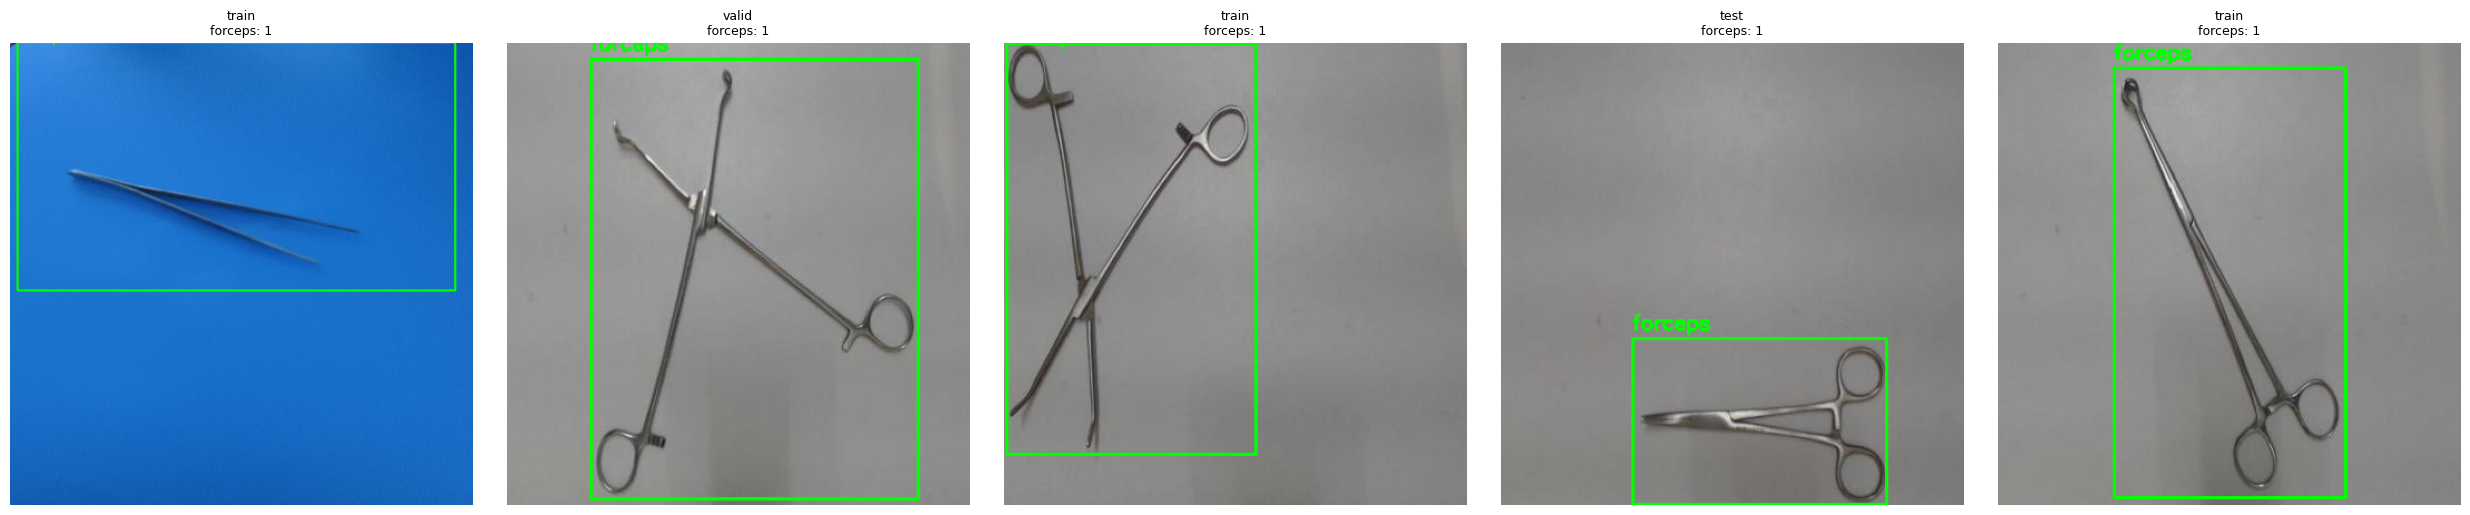

Found 1210 candidate images for 'bp_handle'


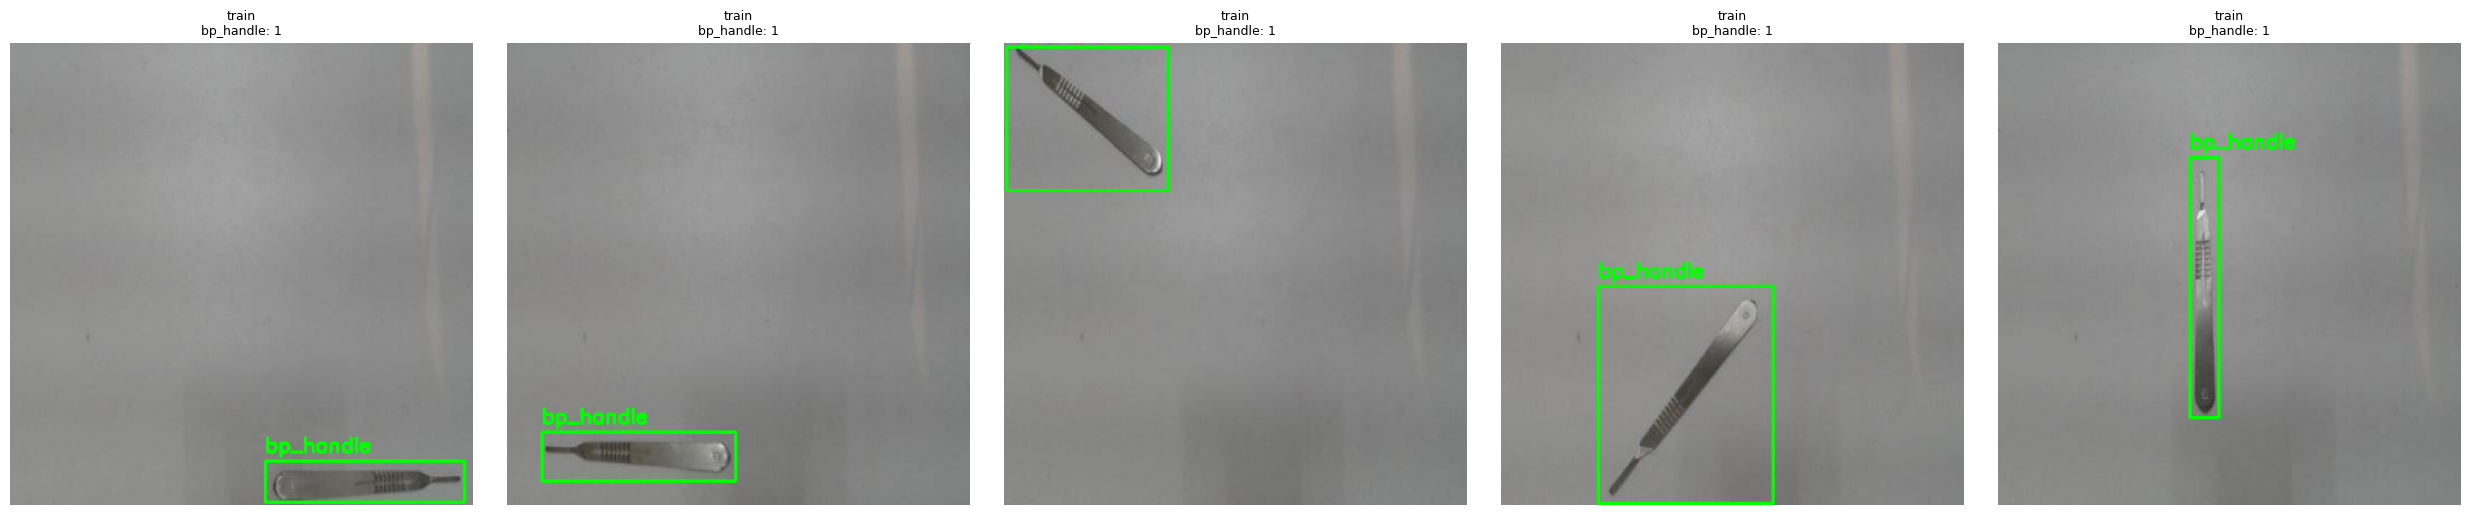

Found 809 candidate images for 'dissector'


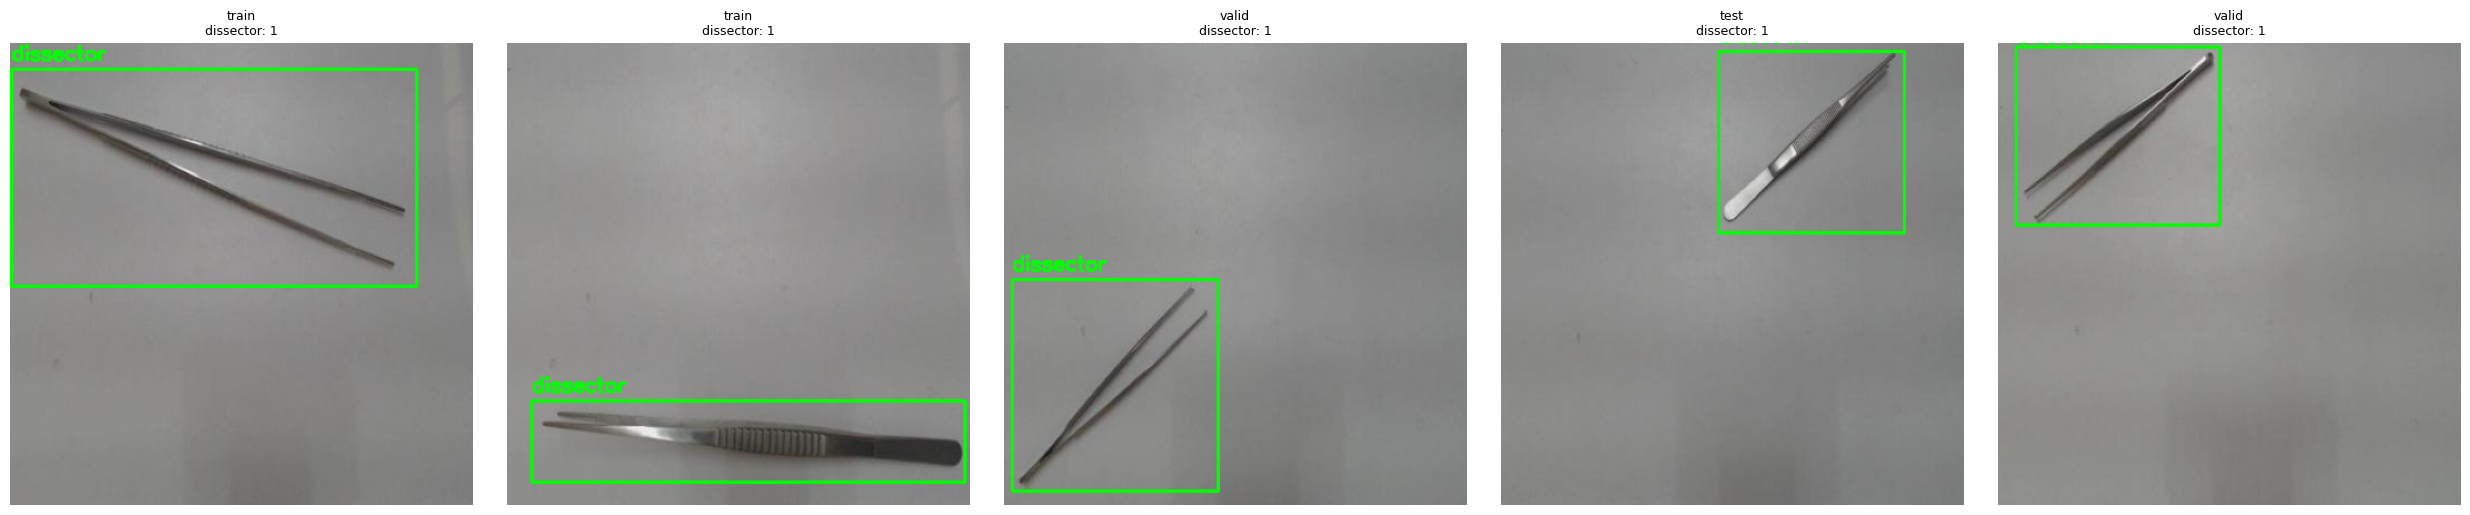

Found 619 candidate images for 'scalpel'


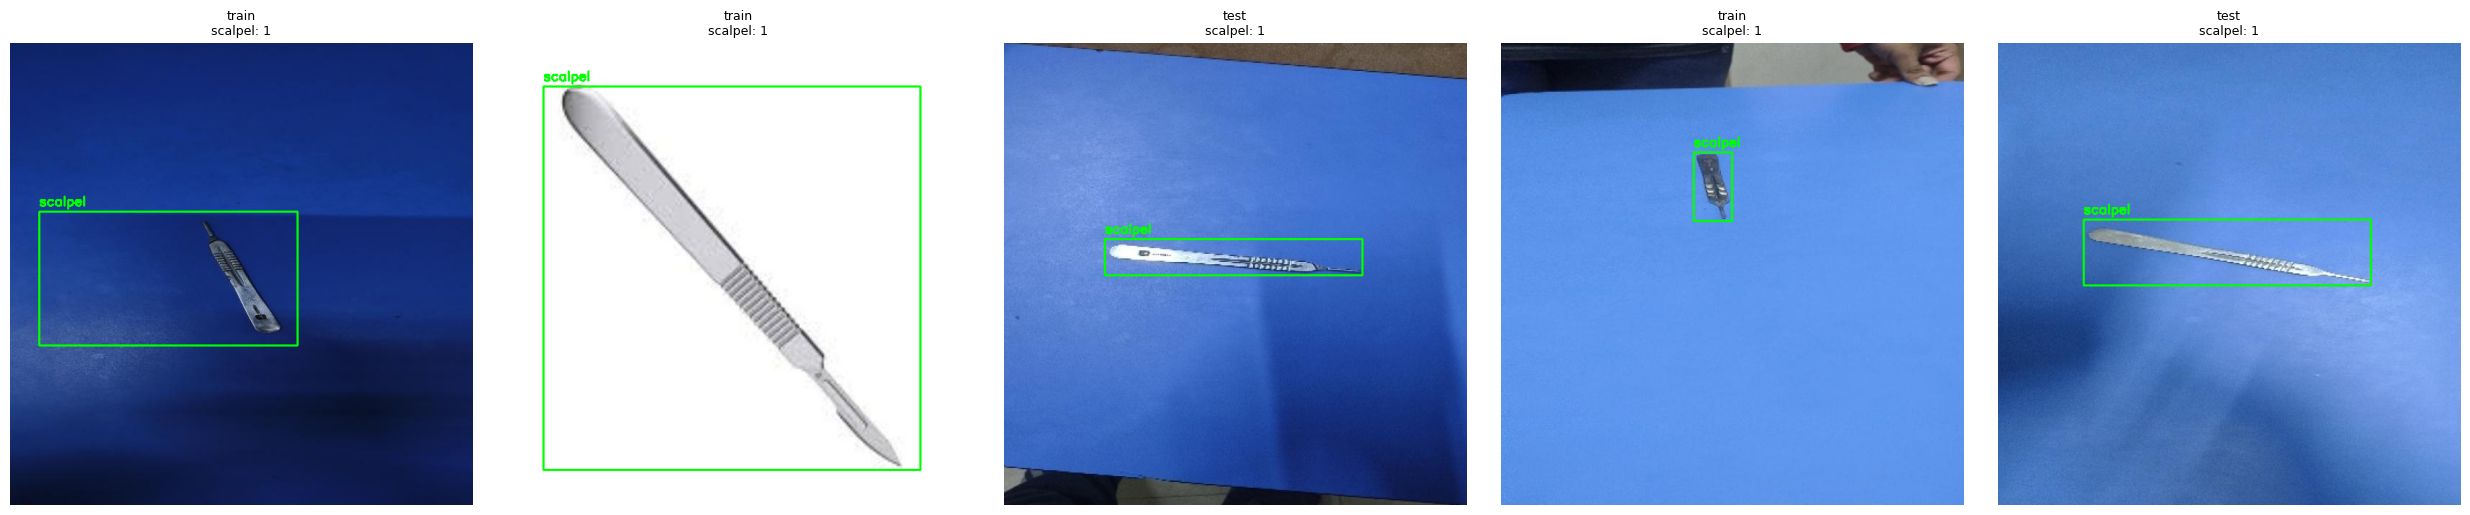

Found 603 candidate images for 'syringe'


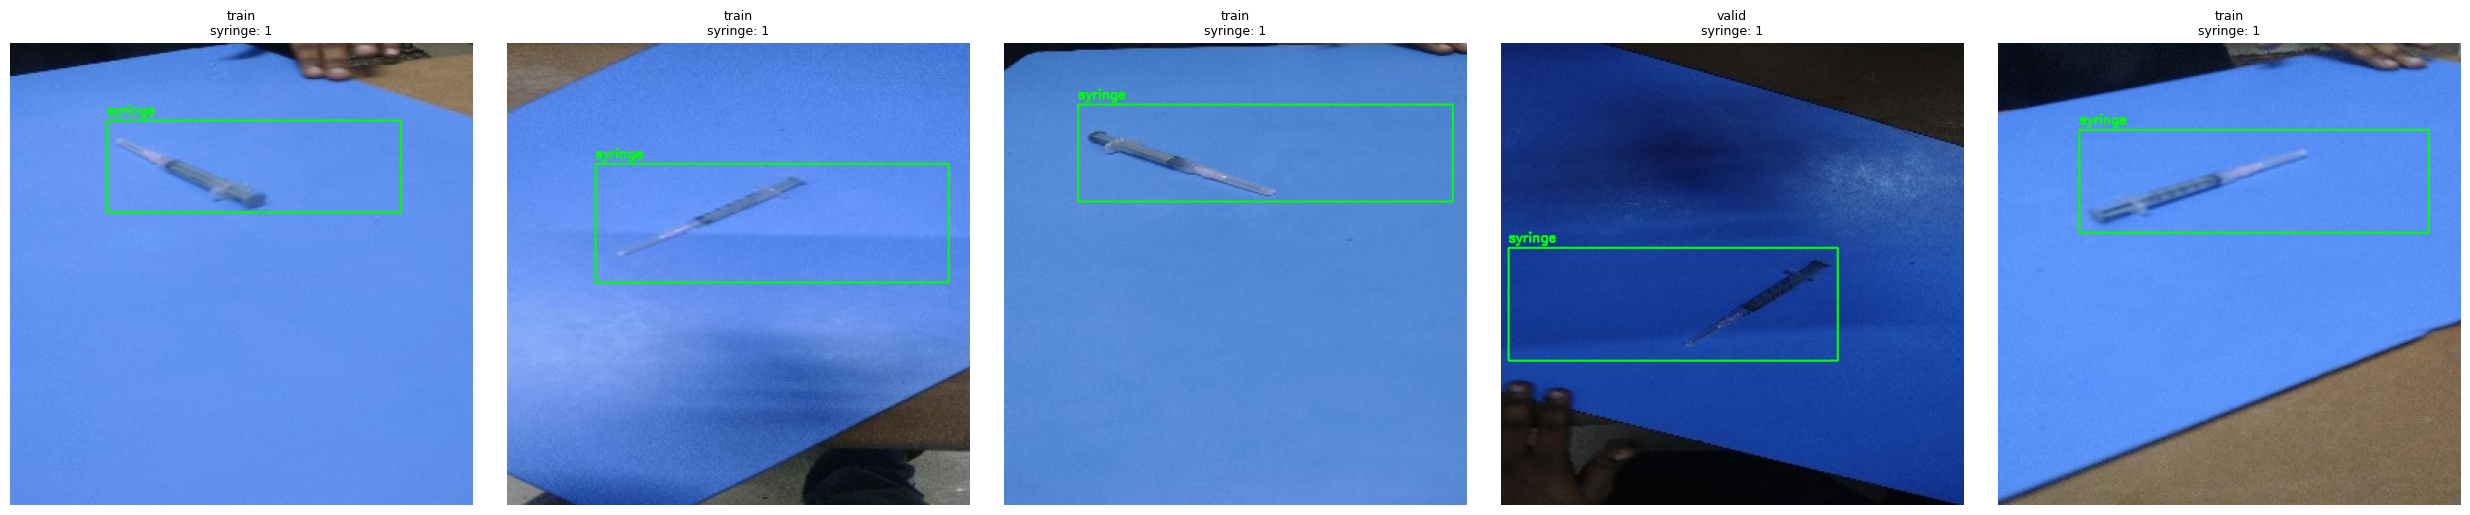

In [12]:

# SANITY CHECK - SEE WHAT EACH CLASS CONTAINS
# selects 5 random images from each class each time
# make sure the images for each look reasonable
import os
import random
import cv2
import matplotlib.pyplot as plt

class_id_to_name = {
    0: "scissors",
    1: "forceps",
    2: "bp_handle",
    3: "dissector",
    4: "scalpel",
    5: "syringe",
}

def parse_yolo_label(label_path):
    anns = []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            class_id = int(parts[0])
            x_center, y_center, bw, bh = map(float, parts[1:5])
            anns.append((class_id, x_center, y_center, bw, bh))
    return anns

def load_image_label_pairs(dataset_path):
    pairs = []
    for split in ["train", "valid", "test"]:
        img_dir = os.path.join(dataset_path, split, "images")
        lbl_dir = os.path.join(dataset_path, split, "labels")

        if not os.path.isdir(img_dir) or not os.path.isdir(lbl_dir):
            continue

        for lbl_file in os.listdir(lbl_dir):
            if not lbl_file.endswith(".txt"):
                continue

            stem = os.path.splitext(lbl_file)[0]

            img_path = None
            for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
                candidate = os.path.join(img_dir, stem + ext)
                if os.path.exists(candidate):
                    img_path = candidate
                    break

            if img_path:
                pairs.append((img_path, os.path.join(lbl_dir, lbl_file), split))

    return pairs

def draw_target_class_boxes(img, anns, target_class_id, class_id_to_name):
    h, w = img.shape[:2]
    for class_id, x_center, y_center, bw, bh in anns:
        if class_id != target_class_id:
            continue
        x1 = int((x_center - bw / 2) * w)
        y1 = int((y_center - bh / 2) * h)
        x2 = int((x_center + bw / 2) * w)
        y2 = int((y_center + bh / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, class_id_to_name[target_class_id], (x1, max(0, y1 - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    return img

def show_random_images_for_class(dataset_path, class_id_to_name, target_class_name, n=5, single_class_only=False):
    name_to_class_id = {v: k for k, v in class_id_to_name.items()}
    target_class_id = name_to_class_id[target_class_name]

    pairs = load_image_label_pairs(dataset_path)
    candidates = []

    for img_path, label_path, split in pairs:
        anns = parse_yolo_label(label_path)
        classes_present = set(a[0] for a in anns)

        if target_class_id not in classes_present:
            continue
        if single_class_only and classes_present != {target_class_id}:
            continue

        target_count = sum(1 for a in anns if a[0] == target_class_id)
        candidates.append((img_path, label_path, split, target_count, classes_present))

    print(f"Found {len(candidates)} candidate images for '{target_class_name}'")

    if not candidates:
        return

    chosen = random.sample(candidates, min(n, len(candidates)))
    fig, axes = plt.subplots(1, len(chosen), figsize=(5 * len(chosen), 5))
    if len(chosen) == 1:
        axes = [axes]

    for ax, (img_path, label_path, split, target_count, classes_present) in zip(axes, chosen):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        anns = parse_yolo_label(label_path)
        img = draw_target_class_boxes(img, anns, target_class_id, class_id_to_name)

        other_classes = [class_id_to_name[c] for c in classes_present if c != target_class_id]

        title = f"{split}\n{target_class_name}: {target_count}"
        if other_classes:
            title += f"\n+ {', '.join(other_classes)}"

        ax.imshow(img)
        ax.axis("off")
        ax.set_title(title, fontsize=9)

    plt.tight_layout()
    plt.show()

for class_name in class_id_to_name.values():
    show_random_images_for_class("d1d2_stratified", class_id_to_name, class_name, n=5)


In [14]:
# IMAGE AUGMENTATION
# augment only the training split
# If needed:
# !pip install -q albumentations opencv-python

from pathlib import Path
import cv2
import shutil
import random
import numpy as np
import albumentations as A

SRC = Path("d1d2_stratified")
DST = Path("d1d2_aug_train_only")

CLASS_NAMES = [
    "scissors",
    "forceps",
    "bp_handle",
    "dissector",
    "scalpel",
    "syringe",
]

AUGS_PER_IMAGE = 2
random.seed(42)
np.random.seed(42)

transform = A.Compose(
    [
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 7), p=1.0), # defocus blur
            A.MotionBlur(blur_limit=(3, 7), p=1.0), # motion blur
        ], p=0.30),

        A.GaussNoise(std_range=(0.02, 0.07), mean_range=(0.0, 0.0), p=0.30),

        A.RandomBrightnessContrast(
            brightness_limit=(-0.35, 0.10), #low light to slightly brighter
            contrast_limit=(-0.15, 0.10),
            p=0.35
        ),

        # transformations
        A.Affine(
            scale=(0.90, 1.10), # zoom in/out
            translate_percent={"x": (-0.08, 0.08), "y": (-0.08, 0.08)}, # lateral
            rotate=(-15, 15), #rotation
            shear=(-5, 5), #slanting image
            fit_output=False,
            border_mode=cv2.BORDER_CONSTANT,
            fill=0,
            p=0.60,
        ),

        A.CoarseDropout( # occlusion - adds random black patches
            num_holes_range=(1, 4),
            hole_height_range=(0.08, 0.18),
            hole_width_range=(0.08, 0.18),
            fill=0,
            p=0.30,
        ),

        A.OneOf([
            A.ImageCompression(quality_range=(40, 70), p=1.0),
            A.ISONoise(color_shift=(0.01, 0.04), intensity=(0.05, 0.20), p=1.0),
        ], p=0.15),
    ],
    bbox_params=A.BboxParams(
        format="yolo",
        label_fields=["class_labels"],
        min_visibility=0.25,
        clip=True,
    ),
)

def read_yolo_labels(label_path):
    bboxes, class_labels = [], []
    if not label_path.exists():
        return bboxes, class_labels

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls = int(parts[0])
            x, y, w, h = map(float, parts[1:])
            bboxes.append([x, y, w, h])
            class_labels.append(cls)

    return bboxes, class_labels

def write_yolo_labels(label_path, bboxes, class_labels):
    with open(label_path, "w") as f:
        for cls, (x, y, w, h) in zip(class_labels, bboxes):
            f.write(f"{cls} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

def copy_split(split):
    src_img_dir = SRC / split / "images"
    src_lbl_dir = SRC / split / "labels"
    dst_img_dir = DST / split / "images"
    dst_lbl_dir = DST / split / "labels"

    dst_img_dir.mkdir(parents=True, exist_ok=True)
    dst_lbl_dir.mkdir(parents=True, exist_ok=True)

    for p in src_img_dir.iterdir():
        if p.is_file():
            shutil.copy2(p, dst_img_dir / p.name)

    for p in src_lbl_dir.iterdir():
        if p.is_file():
            shutil.copy2(p, dst_lbl_dir / p.name)

# Fresh output folder
if DST.exists():
    shutil.rmtree(DST)

# Copy all original splits first
for split in ["train", "valid", "test"]:
    copy_split(split)

# Augment train only
train_img_dir = SRC / "train" / "images"
train_lbl_dir = SRC / "train" / "labels"
out_train_img_dir = DST / "train" / "images"
out_train_lbl_dir = DST / "train" / "labels"

img_files = [
    p for p in train_img_dir.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
]

print(f"Original train images: {len(img_files)}")

created = 0
skipped_empty = 0
skipped_failed = 0

for i, img_path in enumerate(img_files, 1):
    label_path = train_lbl_dir / f"{img_path.stem}.txt"

    image = cv2.imread(str(img_path))
    if image is None:
        skipped_failed += 1
        continue

    bboxes, class_labels = read_yolo_labels(label_path)

    # Skip unlabeled/background images
    if len(bboxes) == 0:
        skipped_empty += 1
        continue

    for aug_idx in range(AUGS_PER_IMAGE):
        try:
            augmented = transform(image=image, bboxes=bboxes, class_labels=class_labels)
            aug_img = augmented["image"]
            aug_bboxes = augmented["bboxes"]
            aug_labels = augmented["class_labels"]

            # Skip augmented copy if all boxes disappeared
            if len(aug_bboxes) == 0:
                continue

            new_stem = f"{img_path.stem}_aug{aug_idx+1}"
            new_img_path = out_train_img_dir / f"{new_stem}{img_path.suffix}"
            new_lbl_path = out_train_lbl_dir / f"{new_stem}.txt"

            cv2.imwrite(str(new_img_path), aug_img)
            write_yolo_labels(new_lbl_path, aug_bboxes, aug_labels)
            created += 1

        except Exception:
            skipped_failed += 1

    if i % 500 == 0:
        print(f"Processed {i}/{len(img_files)} train images")

# Write data.yaml
yaml_text = f"""train: {str((DST / 'train/images').resolve())}
val: {str((DST / 'valid/images').resolve())}
test: {str((DST / 'test/images').resolve())}

nc: {len(CLASS_NAMES)}
names: {CLASS_NAMES}
"""

with open(DST / "data.yaml", "w") as f:
    f.write(yaml_text)

print("\nDone.")
print(f"Augmented train images created: {created}")
print(f"Skipped unlabeled train images: {skipped_empty}")
print(f"Skipped failed cases: {skipped_failed}")
print(f"New dataset: {DST}")


Original train images: 8946
Processed 500/8946 train images
Processed 1000/8946 train images
Processed 1500/8946 train images
Processed 2000/8946 train images
Processed 2500/8946 train images
Processed 3000/8946 train images
Processed 3500/8946 train images
Processed 4000/8946 train images
Processed 4500/8946 train images
Processed 5000/8946 train images
Processed 5500/8946 train images
Processed 6000/8946 train images
Processed 6500/8946 train images
Processed 7000/8946 train images
Processed 7500/8946 train images
Processed 8000/8946 train images
Processed 8500/8946 train images

Done.
Augmented train images created: 17859
Skipped unlabeled train images: 15
Skipped failed cases: 0
New dataset: d1d2_aug_train_only


In [ ]:
# HYPERPARAMETER TUNING

from ultralytics import YOLO
from pathlib import Path
import time

# can use the non-augmented set first for cleaner signal, or swap to the augmented one if you prefer.
# DATA_YAML = Path("/content/d1d2_aug_train_only/data.yaml")
DATA_YAML = Path("d1d2_stratified/data.yaml")

assert DATA_YAML.exists(), f"Missing data.yaml: {DATA_YAML}"

model = YOLO("yolo26n.pt")

start = time.time()


tune_results = model.tune(
    data=str(DATA_YAML),
    epochs=15,
    iterations=30,
    imgsz=640,
    fraction=0.5,
    patience=5,
    optimizer="SGD",
    workers=2,
    batch=16,
    device=0,
    project="runs/detect",
    name="runs/detect/tune_yolo26n_tools",
    plots=True,
    save=True,
    val=True,
    verbose=True,
)

elapsed_min = (time.time() - start) / 60
print(f"Tuning finished in {elapsed_min:.1f} minutes")
print("Results saved under: /content/runs/detect/tune_yolo26n_tools")

import shutil

# This is where YOLO automatically puts the file based on your project/name
tune_dir = Path("tune_yolo26n_tools")
best_yaml = tune_dir / "best_hyperparameters.yaml"

# Sometimes YOLO nests it in an extra 'tune' folder depending on the version
if not best_yaml.exists():
    best_yaml = tune_dir / "tune" / "best_hyperparameters.yaml"

if best_yaml.exists():
    print(f"\n✅ SUCCESS: The best hyperparameters were automatically saved at:\n{best_yaml}")
    
    # Optional: Copy it to your current working directory so it's easier to find!
    shutil.copy(best_yaml, "best_hyperparameters.yaml")
    print("📂 A copy has been saved to your current folder as 'best_hyperparameters.yaml'")
else:
    print("❌ Could not find best_hyperparameters.yaml. Tuning may have been interrupted.")


In [ ]:
best_model = YOLO("yolo26s.pt")
best_model.train(
    data="d1d2_aug_train_only/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="yolo_runs",
    name="final_yolo26s_tools",
)
